<a href="https://colab.research.google.com/github/NainaDua/module2fedex/blob/main/module2_fedex_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -  **FedEx Logistics Performance Analysis**



##### **Project Type**    - EDA
##### **Contribution**    - Individual


# **Problem Statement**


**BUSINESS PROBLEM OVERVIEW**


FedEx Logistics faces the challenge of managing a highly complex and dynamic global supply chain. It needs to coordinate shipments across multiple regions, countries, and industries, navigating diverse regulatory environments, fluctuating demand, and potential disruptions (such as geopolitical issues or natural disasters). The company also struggles with optimizing routes and inventory, minimizing costs, and ensuring timely deliveries while maintaining quality service.

#### **Define Your Business Objective?**

The objective of FedEx Logistics is to enhance operational efficiency, streamline global supply chain processes, and improve customer satisfaction by ensuring timely and cost-effective deliveries. This includes leveraging technology for better route optimization, improving inventory management, ensuring compliance with international regulations, and enhancing the overall scalability and flexibility of their supply chain to adapt to changing market conditions.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
from numpy import math
from numpy import loadtxt
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import rcParams

!pip install pymysql
import pymysql
from sqlalchemy import create_engine
from sqlalchemy.pool import NullPool

import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

data link : https://drive.google.com/file/d/1cC99MjrpyQxu53cP8oGe6R4i_aEkyVZw/view?usp=sharing

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# load and convert into dataframe

data = pd.read_csv('/content/drive/MyDrive/SCMS_Delivery_History_Dataset.csv')
pd.set_option('display.max_columns',None)    # it will help to show all the columns


### Dataset First View

In [ ]:
# by default it gives first 5 rows of data
data.head(2)

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2-Jun-06,2-Jun-06,2-Jun-06,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,NaN,Test kit,30,19,551.0,29.0,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,14-Nov-06,14-Nov-06,14-Nov-06,ARV,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.0,6.2,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns
data.shape

(10324, 33)

### Dataset Information

In [ ]:
# Dataset Info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
# len(data[data.duplicated()])

len(data[data.duplicated()])

0

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
data.isnull().sum()

,0
ID,0
Project Code,0
PQ #,0
PO / SO #,0
ASN/DN #,0
Country,0
Managed By,0
Fulfill Via,0
Vendor INCO Term,0
Shipment Mode,360


### What did you know about your dataset?

The data given from FeDex, and we have to do analysis and insights behind it.

The goal is to achieve seamless and scalable global logistics operations that deliver on-time shipments with reduced costs, increased efficiency, and improved customer satisfaction. By leveraging innovation, technology, and strategic partnerships, FedEx aims to become the leading provider in global supply chain management, fostering growth in new markets, improving service reliability, and enhancing profitability in the long term

The above dataset has 10324 rows and 33 columns. There are some missing values but no duplicate values in the data.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
data.columns

Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')

In [ ]:
# Dataset Describe
data.describe()

,ID,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Line Item Insurance (USD)
count,10324.000000,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10037.000000
mean,51098.968229,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,240.117626
std,31944.332496,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,500.190568
min,1.000000,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,12795.750000,30.000000,408.000000,4.314593e+03,4.120000,0.080000,6.510000
50%,57540.500000,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,47.040000
75%,83648.250000,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,252.400000
max,86823.000000,1000.000000,619999.000000,5.951990e+06,1345.640000,238.650000,7708.440000


### Variables Description

**ID:**  Unique identifier for each logistics record.

**Project Code:**  Code representing the project or initiative tied to the shipment.

**PQ #:**  Price Quotation reference number.

**PO/SO #:** Purchase Order or Sales Order associated with the shipment.

**ASN/DN #:**  Advanced Shipment Notice or Delivery Note reference.

**Country:** Destination country for the shipment (e.g., Côte d'Ivoire, Vietnam).

**Managed By:**  Specifies which team manages the project (e.g., PMO-US).

**Fulfill Via:**  Method of fulfillment, such as direct drop shipment.

**Vendor INCO Term:**  Incoterms defining the shipment agreement (e.g., EXW, FCA).

**Shipment Mode:**  The mode of transportation used (e.g., air).

**PQ First Sent to Client Date:**  The date the Price Quotation was first sent to the client (some records indicate "Pre-PQ Process").

**PO Sent to Vendor Date:**  Date the purchase order was sent to the vendor.

**Scheduled Delivery Date:** The planned date for delivery.

**Delivered to Client Date:**  The actual date the shipment was delivered.

**Delivery Recorded Date:**  Date when delivery was recorded.

**Product Group:**  General classification of the product (e.g., HIV test, ARV Pediatric).

**Sub Classification:**  Further categorization of the product.

**Vendor:**  The company supplying the goods (e.g., RANBAXY Fine Chemicals LTD, Aurobindo Pharma Limited).

**Item Description:**  Detailed description of the item being shipped.

**Molecule/Test Type:**  The type of test or pharmaceutical molecule (e.g., HIV, Nevirapine).

**Brand:**  The brand name of the product (e.g., Reveal, Generic).

**Dosage:**  The dosage strength of the pharmaceutical product (if applicable).

**Dosage Form:**  The form in which the product is delivered (e.g., test kit, oral suspension).

**Unit of Measure (Per Pack):**  The number of units per pack.

**Line Item Quantity:**  The total number of units shipped.

**Line Item Value:**  The total value of the line item in the shipment.

**Pack Price:**  Price per pack of the item.

**Unit Price:**  Price per individual unit of the item.

**Manufacturing Site:**  The location where the item was manufactured (e.g., Ranbaxy Fine Chemicals LTD, Aurobindo Unit III, India).

**First Line Designation:**  Indicates whether the product is designated for first-line use.

**Weight (Kilograms):**  The weight of the shipment.

**Freight Cost (USD):**  The cost of shipping the item in U.S. dollars.

**Line Item Insurance (USD):**  Insurance cost for the line item, if applicable.

### Check Unique Values for each variable.

In [ ]:
for i in data.columns:
  print("No. of unique values in ",i,"is",data[i].nunique(),".")

No. of unique values in  ID is 10324 .
No. of unique values in  Project Code is 142 .
No. of unique values in  PQ # is 1237 .
No. of unique values in  PO / SO # is 6233 .
No. of unique values in  ASN/DN # is 7030 .
No. of unique values in  Country is 43 .
No. of unique values in  Managed By is 4 .
No. of unique values in  Fulfill Via is 2 .
No. of unique values in  Vendor INCO Term is 8 .
No. of unique values in  Shipment Mode is 4 .
No. of unique values in  PQ First Sent to Client Date is 765 .
No. of unique values in  PO Sent to Vendor Date is 897 .
No. of unique values in  Scheduled Delivery Date is 2006 .
No. of unique values in  Delivered to Client Date is 2093 .
No. of unique values in  Delivery Recorded Date is 2042 .
No. of unique values in  Product Group is 5 .
No. of unique values in  Sub Classification is 6 .
No. of unique values in  Vendor is 73 .
No. of unique values in  Item Description is 184 .
No. of unique values in  Molecule/Test Type is 86 .
No. of unique values in  

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

In [ ]:
# convert object datatype into datetime and numeric(integer/float)
num_col = ['Weight (Kilograms)','Freight Cost (USD)','Line Item Insurance (USD)']
for i in num_col:
  data[i]=pd.to_numeric(data[i],errors='coerce')

date_col = ['PO Sent to Vendor Date','Scheduled Delivery Date','Delivered to Client Date']
for i in date_col:
  data[i]=pd.to_datetime(data[i],errors='coerce')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ID                            10324 non-null  int64         
 1   Project Code                  10324 non-null  object        
 2   PQ #                          10324 non-null  object        
 3   PO / SO #                     10324 non-null  object        
 4   ASN/DN #                      10324 non-null  object        
 5   Country                       10324 non-null  object        
 6   Managed By                    10324 non-null  object        
 7   Fulfill Via                   10324 non-null  object        
 8   Vendor INCO Term              10324 non-null  object        
 9   Shipment Mode                 9964 non-null   object        
 10  PQ First Sent to Client Date  10324 non-null  object        
 11  PO Sent to Vendor Date      

In [ ]:
#no.of shipping across different countries
d1 = (data.groupby('Country')['ID'].count().reset_index()).sort_values('ID',ascending=False,ignore_index=True)
d1.columns = ['Country','#ofshipping']
d1

,Country,#ofshipping
0,South Africa,1406
1,Nigeria,1194
2,Côte d'Ivoire,1083
3,Uganda,779
4,Vietnam,688
5,Zambia,683
6,Haiti,655
7,Mozambique,631
8,Zimbabwe,538
9,Tanzania,519


In [ ]:
#which shipment mostly used
d2 = (data.groupby('Shipment Mode')['ID'].count().reset_index()).sort_values('ID',ascending=False,ignore_index=True)
d2.columns = ['Shipment Mode','#times']
d2['#times(%)'] = d2['#times'].apply(lambda x: x/data.shape[0]*100)
d2

,Shipment Mode,#times,#times(%)
0,Air,6113,59.211546
1,Truck,2830,27.411856
2,Air Charter,650,6.296009
3,Ocean,371,3.593568


In [ ]:
# country vs freightcost
d3 = (data.groupby('Country')['Freight Cost (USD)'].mean().round(2).reset_index()).sort_values('Freight Cost (USD)',ascending=False,ignore_index=True)
d3.columns = ['Country','avg FreightCost(USD)']
d3

,Country,avg FreightCost(USD)
0,Cameroon,32006.28
1,Nigeria,18676.11
2,Sierra Leone,18249.26
3,Rwanda,16838.55
4,Kenya,15703.42
5,Zimbabwe,13536.05
6,Pakistan,13298.48
7,Ghana,13162.59
8,Zambia,12205.87
9,Tanzania,11718.42


In [ ]:
d4 = (data.groupby('Country')['Freight Cost (USD)'].mean().round(2).reset_index()).sort_values('Freight Cost (USD)',ascending=True,ignore_index=True).head(5)
d4.columns = ['Country','avg FreightCost(USD)']
d4

,Country,avg FreightCost(USD)
0,Afghanistan,540.52
1,Senegal,722.32
2,Sudan,1493.33
3,Guinea,1804.20
4,Belize,1959.61


In [ ]:
#country vs freight cost(mean,max,min)
d5 = (data.groupby('Country')['Freight Cost (USD)'].agg(['mean','max','min']).round(2).reset_index())
d5

,Country,mean,max,min
0,Afghanistan,540.52,555.49,525.56
1,Angola,4685.24,13790.10,840.17
2,Belize,1959.61,1959.61,1959.61
3,Benin,9430.74,28541.79,1136.37
4,Botswana,2224.68,23796.98,304.76
5,Burkina Faso,NaN,NaN,NaN
6,Burundi,5572.18,33228.68,29.21
7,Cameroon,32006.28,123945.00,549.16
8,"Congo, DRC",6721.95,62196.13,91.42
9,Côte d'Ivoire,8356.88,60432.88,22.29


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - Pie Chart (SHIPPING MODE MOSTLY USED)

In [ ]:
d2 = (data.groupby('Shipment Mode')['ID'].count().reset_index()).sort_values('ID',ascending=False,ignore_index=True)
d2.columns = ['Shipment Mode','#times']
d2['#times(%)'] = d2['#times'].apply(lambda x: x/data.shape[0]*100)
d2

,Shipment Mode,#times,#times(%)
0,Air,6113,59.211546
1,Truck,2830,27.411856
2,Air Charter,650,6.296009
3,Ocean,371,3.593568


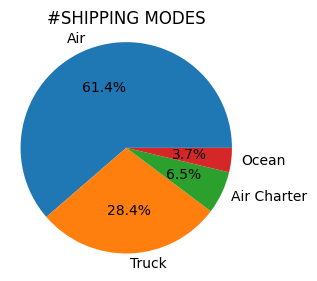

In [ ]:
plt.figure(figsize=(3,3))  #it will handle the size of figure
plt.pie(d2['#times(%)'],labels=d2['Shipment Mode'],autopct='%1.1f%%')
plt.axis('equal')
plt.title('#SHIPPING MODES')
plt.show()


##### 1. Why did you pick the specific chart?

A pie chart expresses a part-to-whole relationship in your data. It's easy to explain the percentage comparison through area covered in a circle with different colors. Where differenet percentage comparison comes into action pie chart is used frequently. So, I used Pie chart and which helped me to get the percentage comparision of the dependant variable.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that FedEx Logistics primarily relies on air transport, which makes up 59.21% of all shipments, highlighting the company's focus on fast, time-sensitive deliveries. Ground transportation (truck) accounts for 27.41%, reflecting the importance of regional and last-mile deliveries. Air charter and ocean shipments, at 6.3% and 3.6%, respectively, are less frequent, suggesting they are used for specialized, large-scale, or less time-sensitive shipments. Overall, the data suggests FedEx maintains a strong balance between speed, efficiency, and cost by leveraging a mix of air, truck, and specialized shipping methods

##### 3. Will the gained insights help creating a positive business impact?


 yeah.. it tells that air charter (6.3%) and ocean shipments (3.6%) are less frequent, they represent niche opportunities. FedEx could explore further developing these services to cater to large, bulk shipments or more specialized international logistics needs, tapping into markets where air transport isn’t cost-efficient.

#### Chart - 2 - BAR GRAPH/COUNT PLOT (NO. OF SHIPPING ACROSS DIFFERENT COUNTRIES)

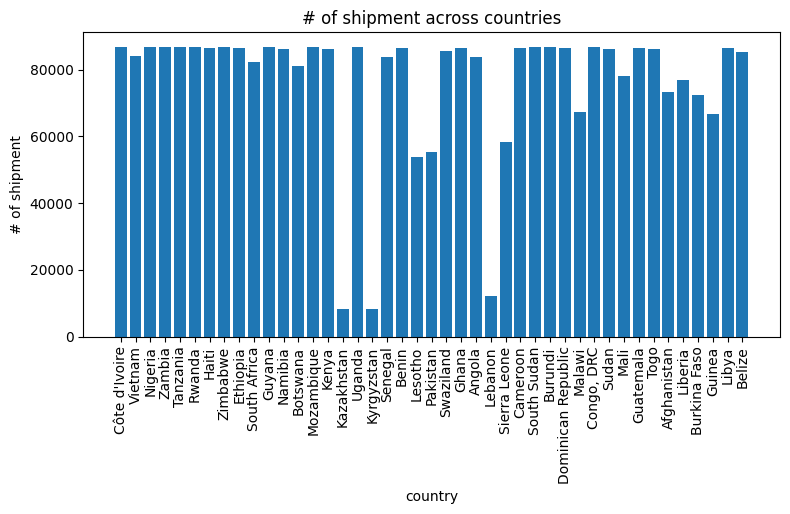

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(data['Country'],data['ID'],data=data)
plt.title('# of shipment across countries')
plt.xlabel('country')
plt.ylabel('# of shipment')
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

In [ ]:
d1 = (data.groupby('Country')['ID'].count().reset_index()).sort_values('ID',ascending=False,ignore_index=True)
d1.columns = ['Country','#ofshipping']
d1

,Country,#ofshipping
0,South Africa,1406
1,Nigeria,1194
2,Côte d'Ivoire,1083
3,Uganda,779
4,Vietnam,688
5,Zambia,683
6,Haiti,655
7,Mozambique,631
8,Zimbabwe,538
9,Tanzania,519


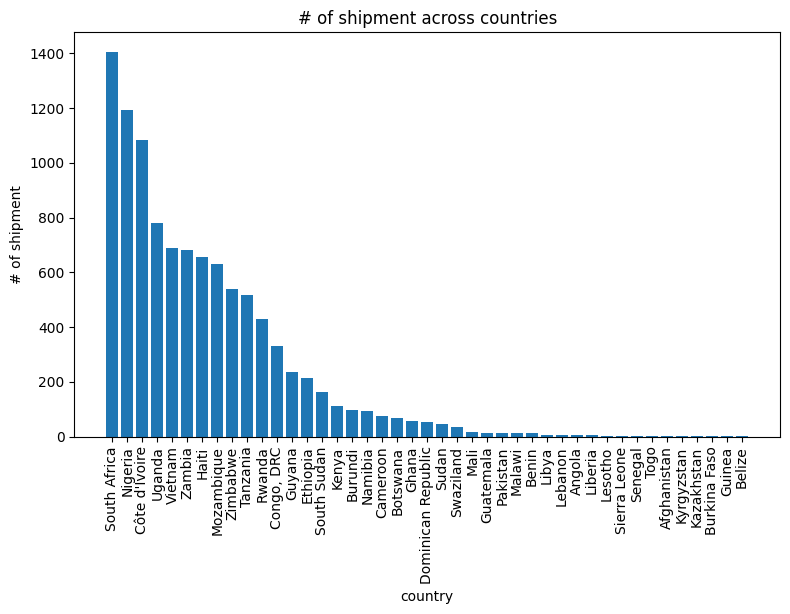

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(d1['Country'],d1['#ofshipping'],data=d1)
plt.title('# of shipment across countries')
plt.xlabel('country')
plt.ylabel('# of shipment')
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

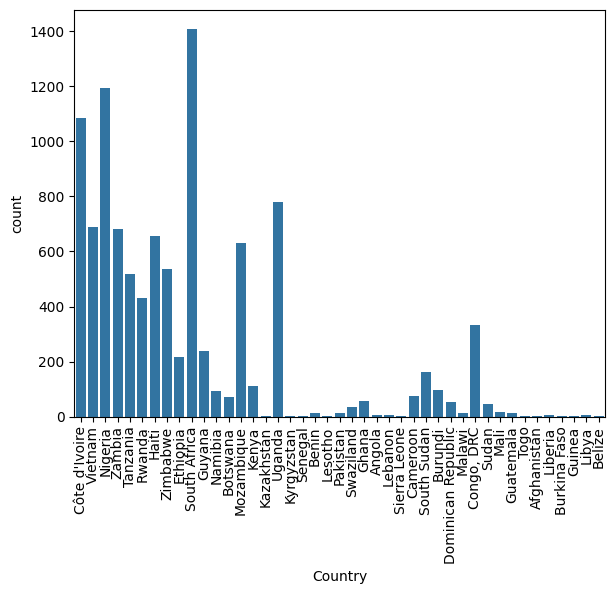

In [ ]:
sns.countplot(x=data['Country'],data=data)
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

##### 1. Why did you pick the specific chart?

Bar charts show the frequency counts of values for the different levels of a categorical or nominal variable.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals that FedEx Logistics has a significant presence in African and Caribbean countries, with South Africa (1406 shipments), Nigeria (1194), and Côte d'Ivoire (1083) leading in shipments. This suggests a strong focus on emerging markets in Africa, where demand for logistics services is growing. Countries like Uganda, Zambia, and Haiti also show notable shipment volumes, indicating that FedEx is effectively serving both well-established and developing regions. However, there are smaller markets, such as Guinea, Belize, and Kazakhstan, with very few shipments, which might represent either underdeveloped demand or limited market penetration. Overall, the data highlights FedEx’s extensive reach in diverse regions, while also pointing to opportunities for expanding in countries with lower shipment volumes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, It tells that The lower shipment volumes in countries like Guinea, Belize, and Kazakhstan represent potential opportunities. FedEx could analyze the reasons for the low shipment numbers—whether it's due to low market demand, limited local infrastructure, or competition—and then design targeted strategies to increase penetration in these countries, potentially boosting revenue.

#### Chart - 3 - BOX PLOT (DIST. OF SHIPPING COST ACROSS DIFFERENT COUNTRIES)

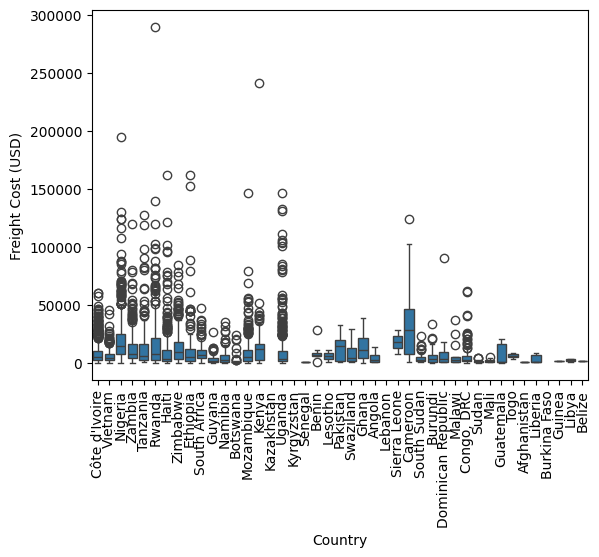

In [ ]:
sns.boxplot(x=data['Country'],y=data['Freight Cost (USD)'],data=data)
plt.xticks(rotation=90)
plt.show()

##### 1. Why did you pick the specific chart?


I’d pick a boxplot because it effectively shows the distribution of shipment data, highlighting key statistics like the median, quartiles, and any potential outliers. It helps identify patterns, trends, and regions with unusually high or low shipment volumes, making it easy to spot areas for improvement or focus. A boxplot provides a clear and concise view of data spread, which is ideal for understanding the overall shipment landscape

##### 2. What is/are the insight(s) found from the chart?

The freight cost data reveals significant variation across countries, with some nations incurring much higher logistics avg costs than others. For instance, Cameroon (32,006.28 USD), Sierra Leone (18,249.27 USD), and Nigeria (18,676.11 USD) have the highest freight costs, potentially due to factors like distance, infrastructure challenges, or high demand for expedited deliveries. In contrast, countries like Afghanistan (540.53 USD) and Senegal (722.32 USD) have relatively low freight costs, which might reflect less complex logistics requirements or smaller shipment volumes. There are also some missing values (NaN) for countries like Burkina Faso, Kazakhstan, and Kyrgyzstan, which need to be addressed for a complete analysis. Overall, the data highlights the uneven nature of freight costs, where geographic, infrastructural, and economic factors play a significant role in determining logistics expenses.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The variation in freight costs across countries provides an opportunity for FedEx to optimize operations. By identifying regions with higher freight costs (like Cameroon, Sierra Leone, and Nigeria), FedEx can analyze the factors driving these costs, such as infrastructure limitations or longer delivery routes, and invest in cost-reduction strategies. For example, improving local logistics infrastructure, or using alternative transportation methods, could help lower costs in these regions, boosting overall profitability.

#### Chart - 4 - SCATTER PLOT (WEIGHT VS FREIGHT)

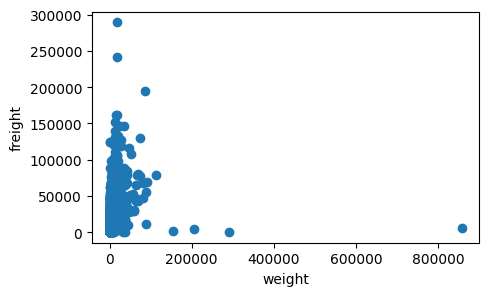

In [ ]:
plt.figure(figsize=(5,3))
plt.scatter(data['Weight (Kilograms)'],data['Freight Cost (USD)'])
plt.xlabel('weight')
plt.ylabel('freight')
plt.show()

##### 1. Why did you pick the specific chart?

A scatterplot for freight cost vs. weight is useful because it visually shows how freight costs change in relation to shipment weight. By plotting this data, you can easily identify trends, such as whether heavier shipments consistently lead to higher costs. The scatterplot also helps detect outliers, where certain shipments might have unusually high or low costs for their weight, which could highlight inefficiencies or opportunities for optimization in pricing or logistics strategies

To show the average percentage of true churn with respect to Area Code, I have used Bar Chart.

##### 2. What is/are the insight(s) found from the chart?

Most shipments have lower weights, with freight costs varying widely within this range. There are a few high-weight shipments that stand out as outliers, with one shipment having an exceptionally high weight and a relatively low freight cost. This could indicate bulk shipping discounts, pricing anomalies, or special handling conditions. The pattern suggests that freight cost does not always increase proportionally with weight, highlighting potential cost inefficiencies or strategic pricing in the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

By recognizing that freight costs don't always increase proportionally with weight, the business can reconsider its pricing model to ensure it is aligned with true cost drivers. This might involve introducing a more dynamic pricing structure based on factors like shipment size, route, and special handling conditions.
If there are bulk shipping discounts or special pricing arrangements, the business can optimize these offers to retain customers or improve margins without underpricing large shipments.

#### Chart - 5 - BAR PLOT (#DAYS IN DELIVERED)

In [ ]:
data['days']=(data['Delivered to Client Date']-data['Scheduled Delivery Date']).dt.days

In [ ]:
data[data['days']>0].shape  #dealys

(1186, 34)

In [ ]:
data[data['days']<=0].shape   #advance and same day

(9138, 34)

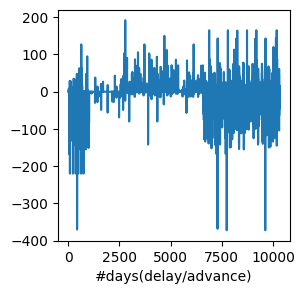

In [ ]:
plt.figure(figsize=(3,3))
plt.plot(data['days'])
plt.xlabel('#days(delay/advance)')
plt.show()

Text(0.5, 0, '#days(delay/advance)')

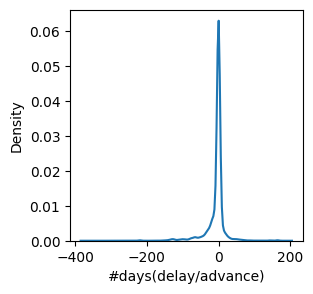

In [ ]:
plt.figure(figsize=(3,3))
sns.kdeplot(data=data['days'])
plt.xlabel('#days(delay/advance)')

##### 1. Why did you pick the specific chart?

A line plot is particularly useful when you want to show the relationship between two continuous variables or track changes over time. In the context of "days" (which includes both delays and advances),

##### 2. What is/are the insight(s) found from the chart?

The line chart of delivery performance reveals significant fluctuations in the number of days taken for delivery, with values ranging from highly negative to considerably positive. This indicates that while some deliveries were completed much earlier than the scheduled date, others experienced substantial delays. The presence of extreme negative values suggests possible early deliveries, whereas the spikes in the positive range highlight recurring delays in the delivery process. Additionally, clusters of data points around the zero line indicate periods of relatively on-time deliveries. However, the irregular patterns and sudden deviations suggest inconsistencies in the supply chain or potential data quality issues, such as incorrect date entries or missing information. These findings emphasize the need for further investigation into the root causes of delivery delays and early shipments to optimize scheduling and improve overall efficiency.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights found will definitely help for a positive business impact. The insight that there are recurring delays and early deliveries indicates potential inefficiencies or bottlenecks in the supply chain. By investigating the underlying causes (e.g., production delays, transportation issues, or poor demand forecasting), the business can take corrective action to optimize processes and ensure that products are delivered closer to the expected timeframe.
Positive impact: Reducing delays and minimizing early deliveries can enhance customer satisfaction and operational efficiency

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

**Possible Solutions Based on Insights**

1. **Optimization of Shipping Modes:**  
   - Since air shipping is the dominant mode (61.4%), explore cost-effective alternatives like ocean or trucking where feasible to reduce expenses.  

2. **Country-Specific Cost Analysis:**  
   - Focus on countries with higher freight cost variability to identify potential inefficiencies or renegotiate contracts.  

3. **Weight Distribution Strategy:**  
   - Address clusters of low-weight shipments that may be driving up overall costs by consolidating them for better efficiency.  

4. **Route and Distance Optimization:**  
   - Utilize insights from the time series data to optimize delivery routes and avoid delays or cost spikes.  

5. **Target High-Volume Regions:**  
   - South Africa and other high-shipment countries should be analyzed for potential bulk shipping agreements to leverage economies of scale.


